# Face Recognition Training and Evaluation

This notebook runs the canonical ArcFace training pipeline, reads the recorded MLflow history, evaluates the saved checkpoint, and stores plots and test metrics in the same MLflow run.

The verification threshold is selected on validation identities only. The identity-disjoint test split is used only for the final report.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import mlflow
import pandas as pd
import torch
from mlflow import MlflowClient

from config import (
    CELEBA_MANIFESTS_DIR, CELEBA_RAW_DIR, CHECKPOINTS_DIR,
    MLFLOW_EXPERIMENT_NAME,
)
from data import CelebAFaceDataset
from evaluation import EvaluationConfig, evaluate_checkpoint
from training import DEFAULT_TRACKING_URI, TrainingConfig, train

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

b:\My Personal Projects\face-recognition\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce GTX 1650


## 3. Train and save the model

FULL_TRAINING = False runs a manageable five-epoch development experiment. Set it to True to use all training identities for ten epochs. Every completed epoch overwrites checkpoints/last.pt, and MLflow records parameters and metrics.

In [2]:
RUN_TRAINING = True
FULL_TRAINING = True

if FULL_TRAINING:
    training_config = TrainingConfig(
        run_name='notebook-full-training',
        epochs=5,
        batch_size=32,
        device='cuda',
    )
else:
    training_config = TrainingConfig(
        run_name='notebook-development-training',
        identity_limit=100,
        batch_limit=50,
        validation_batch_limit=20,
        epochs=5,
        batch_size=32,
        num_workers=0,
        device='cuda',
    )

training_result = train(training_config) if RUN_TRAINING else None
if training_result is not None:
    display(training_result)
    print(f'Saved checkpoint: {training_result.checkpoint_path}')

Validation: 100%|██████████| 50/50 [00:29<00:00,  1.69it/s]


TrainingResult(run_id='80c7016d4b04410b940a3988edc3c6a6', completed_epochs=5, checkpoint_path=WindowsPath('B:/My Personal Projects/face-recognition/checkpoints/last.pt'))

Saved checkpoint: B:\My Personal Projects\face-recognition\checkpoints\last.pt


## 4. Select the recorded MLflow run

When training was skipped, the notebook uses the latest finished run and the local last.pt checkpoint.

In [8]:
mlflow.set_tracking_uri(DEFAULT_TRACKING_URI)
experiment = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT_NAME)
if experiment is None:
    raise RuntimeError('No MLflow experiment exists. Run the training cell first.')

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="attributes.status = 'FINISHED'",
    order_by=['start_time DESC'],
)
if runs.empty:
    raise RuntimeError('No finished MLflow run exists. Run the training cell first.')

run_id = training_result.run_id if training_result is not None else runs.iloc[0]['run_id']
checkpoint_path = (
    training_result.checkpoint_path
    if training_result is not None
    else CHECKPOINTS_DIR / 'last.pt'
)
selected_run = MlflowClient().get_run(run_id)
display(pd.Series(selected_run.data.params, name='value').to_frame())
print('Run ID:', run_id)
print('Checkpoint:', checkpoint_path)

,value
train_manifest,B:\My Personal Projects\face-recognition\data\...
validation_manifest,B:\My Personal Projects\face-recognition\data\...
dataset_root,B:\My Personal Projects\face-recognition\data\...
run_name,notebook-full-training
embedding_dim,128
arcface_margin_degrees,28.6
arcface_scale,64
batch_size,32
learning_rate,0.01
epochs,5


Run ID: 80c7016d4b04410b940a3988edc3c6a6
Checkpoint: B:\My Personal Projects\face-recognition\checkpoints\last.pt


## 5. Training metric history

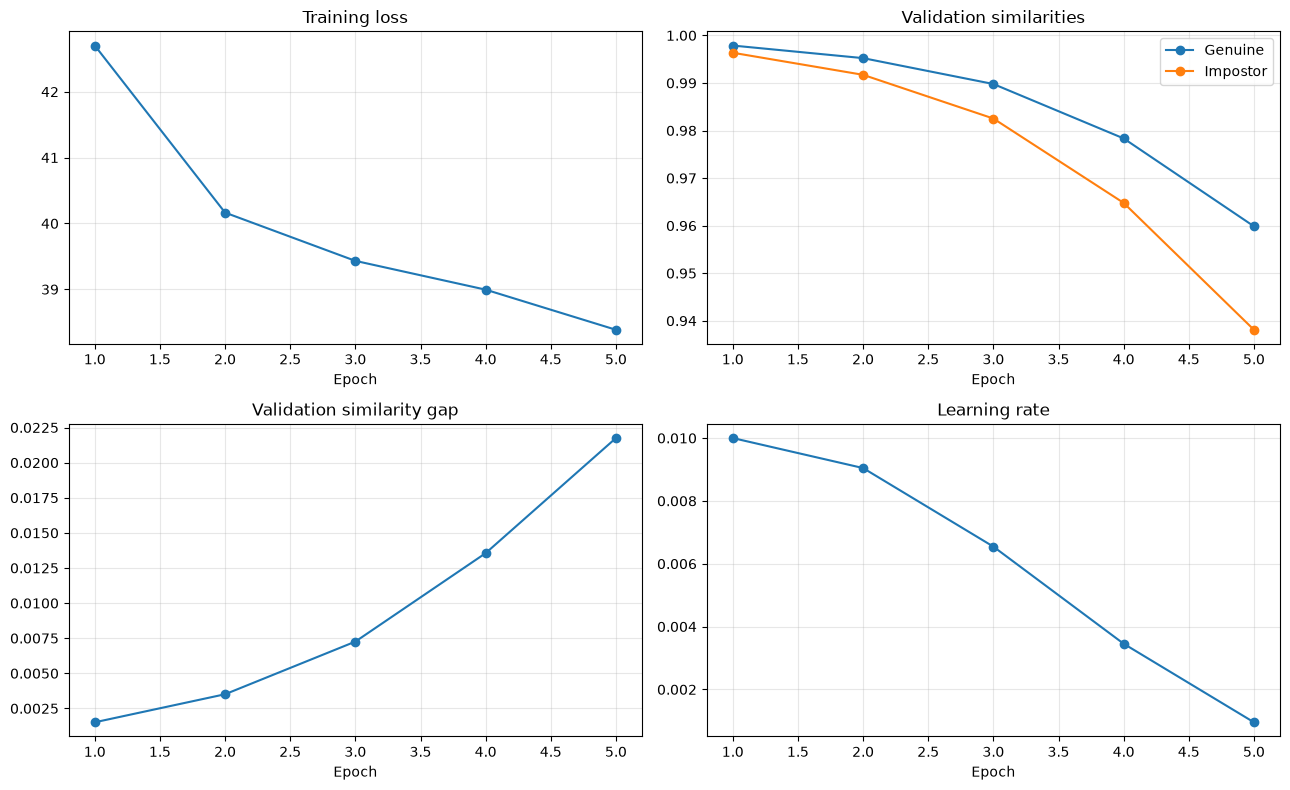

In [9]:
client = MlflowClient()

def metric_history(metric_name):
    history = client.get_metric_history(run_id, metric_name)
    return [point.step for point in history], [point.value for point in history]

metric_history_figure, axes = plt.subplots(2, 2, figsize=(13, 8))

steps, values = metric_history('train/loss')
axes[0, 0].plot(steps, values, marker='o')
axes[0, 0].set_title('Training loss')

for metric_name, label in (
    ('validation/genuine_similarity_mean', 'Genuine'),
    ('validation/impostor_similarity_mean', 'Impostor'),
):
    steps, values = metric_history(metric_name)
    axes[0, 1].plot(steps, values, marker='o', label=label)
axes[0, 1].set_title('Validation similarities')
axes[0, 1].legend()

steps, values = metric_history('validation/similarity_gap')
axes[1, 0].plot(steps, values, marker='o')
axes[1, 0].set_title('Validation similarity gap')

steps, values = metric_history('train/learning_rate')
axes[1, 1].plot(steps, values, marker='o')
axes[1, 1].set_title('Learning rate')

for axis in axes.flat:
    axis.set_xlabel('Epoch')
    axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Validation threshold and test metrics

The evaluator creates one genuine pair and one impostor pair per identity. It selects the threshold on validation scores and applies that unchanged threshold to the test scores.

In [5]:
evaluation_identity_limit = None if FULL_TRAINING else training_config.identity_limit
common_evaluation = {
    'checkpoint_path': checkpoint_path,
    'dataset_root': CELEBA_RAW_DIR,
    'embedding_dim': training_config.embedding_dim,
    'batch_size': training_config.batch_size,
    'num_workers': training_config.num_workers,
    'identity_limit': evaluation_identity_limit,
    'device': training_config.device,
}

validation_evaluation = evaluate_checkpoint(
    EvaluationConfig(
        manifest_path=CELEBA_MANIFESTS_DIR / 'validation.csv',
        **common_evaluation,
    )
)
test_evaluation = evaluate_checkpoint(
    EvaluationConfig(
        manifest_path=CELEBA_MANIFESTS_DIR / 'test.csv',
        **common_evaluation,
    ),
    threshold=validation_evaluation.threshold,
)

evaluation_table = pd.DataFrame(
    [validation_evaluation.metrics, test_evaluation.metrics],
    index=['validation', 'test'],
).T
display(evaluation_table.style.format('{:.4f}'))

Evaluation: 100%|██████████| 633/633 [02:07<00:00,  4.97it/s]


,validation,test
threshold,0.9745,0.9745
accuracy,0.6163,0.6110
precision,0.6432,0.6208
recall_tar,0.5224,0.5703
f1,0.5766,0.5945
far,0.2898,0.3483
frr,0.4776,0.4297
roc_auc,0.6589,0.6565
eer,0.3939,0.3921
genuine_similarity_mean,0.9612,0.9633


## 7. Genuine and impostor score distributions

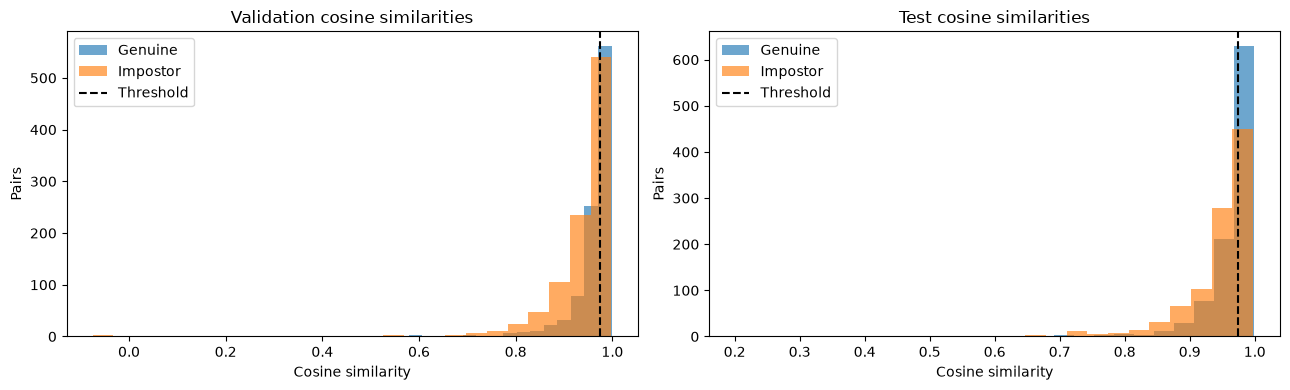

In [6]:
score_distribution_figure, axes = plt.subplots(1, 2, figsize=(13, 4))
for axis, title, evaluation in (
    (axes[0], 'Validation', validation_evaluation),
    (axes[1], 'Test', test_evaluation),
):
    axis.hist(evaluation.genuine_scores, bins=25, alpha=0.65, label='Genuine')
    axis.hist(evaluation.impostor_scores, bins=25, alpha=0.65, label='Impostor')
    axis.axvline(validation_evaluation.threshold, color='black', linestyle='--', label='Threshold')
    axis.set_title(f'{title} cosine similarities')
    axis.set_xlabel('Cosine similarity')
    axis.set_ylabel('Pairs')
    axis.legend()
plt.tight_layout()
plt.show()

## 8. Save evaluation metrics and plots to MLflow

In [7]:
with mlflow.start_run(run_id=run_id):
    mlflow.log_metrics({
        **{f'validation_final/{key}': value for key, value in validation_evaluation.metrics.items()},
        **{f'test/{key}': value for key, value in test_evaluation.metrics.items()},
    })
    mlflow.log_figure(metric_history_figure, 'plots/metric_history.png')
    mlflow.log_figure(score_distribution_figure, 'plots/score_distributions.png')

artifacts = client.list_artifacts(run_id)
display(pd.DataFrame(
    [{'path': artifact.path, 'is_directory': artifact.is_dir} for artifact in artifacts]
))
print('Model checkpoint:', checkpoint_path)
print('MLflow run:', run_id)

,path,is_directory
0,checkpoints,True
1,data,True
2,plots,True


Model checkpoint: B:\My Personal Projects\face-recognition\checkpoints\last.pt
MLflow run: 80c7016d4b04410b940a3988edc3c6a6


## How to interpret the metrics

- **ROC AUC**: how well genuine and impostor scores are separated; closer to 1 is better.
- **FAR**: fraction of impostor pairs incorrectly accepted; lower is better.
- **FRR**: fraction of genuine pairs incorrectly rejected; lower is better.
- **TAR / recall**: fraction of genuine pairs accepted; higher is better.
- **EER**: operating point where FAR and FRR are approximately equal; lower is better.

Do not repeatedly tune the model using the test results. Change the model using training and validation evidence, then use test once for the final report.